The goal of this notebook is to create a non-deep learning baseline model for classifying simplified level of fouling (SLoF) for a data set of underwater images.

In [2]:
import pandas as pd
import imageio.v2 as imageio
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import skimage.measure
import time
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

In [3]:
data_dir = 'data-biofouling/'
image_dir = 'data-biofouling/images/'
metadata_filename = 'metadata.csv'

In [4]:
# Loading the metadata csv file
df = pd.read_csv(data_dir + metadata_filename)

In [5]:
df.head(5)

,image.name,dataset.name,vessel.id,niche.area,SLoF,paint.quality,split
0,000001-GNZuCtwed3.jpg,commercial-1,8,hull,0,3,training
1,000002-CAgNlUizNm.jpg,commercial-1,8,hull,0,3,training
2,000003-vDe7GN0NrL.jpg,commercial-1,8,hull,0,2,training
3,000004-TbUBpfn6iP.jpg,commercial-1,8,hull,0,2,training
4,000005-oemYWm1Tjg.jpg,commercial-1,8,hull,0,3,training


In [6]:
df['split'].value_counts()

split
training      9422
validation     841
Name: count, dtype: int64

In [7]:
# divide up the training data into training and test
validation_size = df['split'].value_counts()['validation']
test_size = validation_size

# randomly select a subset of the training data of same size as validation, and relabel as test
test_idx = df[df["split"] == "training"].sample(n=test_size, random_state = 0).index
df.loc[test_idx, "split"] = "test"

In [8]:
df['split'].value_counts()

split
training      8581
test           841
validation     841
Name: count, dtype: int64

In [9]:
# numerically encode categorical variables so that we can make a correlation matrix
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include=["object", "category"]):
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

C:\Users\Joshua\AppData\Local\Temp\ipykernel_14120\749817082.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include=["object", "category"]):


In [10]:
df_encoded.head(5)

,image.name,dataset.name,vessel.id,niche.area,SLoF,paint.quality,split
0,0,1,8,5,0,3,1
1,1,1,8,5,0,3,1
2,2,1,8,5,0,2,1
3,3,1,8,5,0,2,1
4,4,1,8,5,0,3,1


In [11]:
# Load all of the images
image_filenames = df['image.name']
images = {}
for filename in image_filenames:
    images[filename] = imageio.imread(image_dir + filename)

In [12]:
# Some ways to measure complexity of an image
# -shannon entropy, implemented in skimage.shannon_entropy
# -gradient_energy, implemented below
# -variance of red/green/blue channels

def gradient_energy(img):
    if img.ndim == 3:
        img = img.mean(axis=2)
    gx, gy = np.gradient(img.astype(float))
    return np.mean(np.sqrt(gx**2 + gy**2))

def laplacian_variance(img):
    if img.ndim == 3:
        img = img.mean(axis=2)
    lap = -4*img + np.roll(img, 1, 0) + np.roll(img, -1, 0) + np.roll(img, 1, 1) + np.roll(img, -1, 1)
    return lap.var()

def channel_variances(img):
    # (red, green, blue)
    variances = np.var(img, axis=(0, 1)) 
    return tuple(variances)

In [13]:
# make an enlarged dataframe including the complexity metrics
def compute_metrics(filename):
    img = images[filename]
    entropy = skimage.measure.shannon_entropy(img)
    grad = gradient_energy(img)
    lap = laplacian_variance(img)
    r_var, g_var, b_var = channel_variances(img)
    return entropy, grad, lap, r_var, g_var, b_var

# Loop over images with a progress bar
results = [compute_metrics(f) for f in tqdm(image_filenames, desc="Processing images")]

# Add results to a copy of the dataframe
df_aug = df.copy()
df_aug[['entropy', 'gradient_energy', 'laplacian_var',
        'red_var', 'green_var', 'blue_var']] = results

Processing images: 100%|██████████| 10263/10263 [12:30<00:00, 13.67it/s]


In [14]:
df_aug.head(5)

,image.name,dataset.name,vessel.id,niche.area,SLoF,paint.quality,split,entropy,gradient_energy,laplacian_var,red_var,green_var,blue_var
0,000001-GNZuCtwed3.jpg,commercial-1,8,hull,0,3,training,7.210319,4.478048,636.869978,1167.255624,1246.322851,908.185944
1,000002-CAgNlUizNm.jpg,commercial-1,8,hull,0,3,training,7.272785,5.438474,651.793542,1431.521255,1157.676356,896.145955
2,000003-vDe7GN0NrL.jpg,commercial-1,8,hull,0,2,training,6.754425,3.899760,672.922542,726.176904,2836.436721,3370.453269
3,000004-TbUBpfn6iP.jpg,commercial-1,8,hull,0,2,training,6.805911,3.346528,638.983190,1927.794439,800.957564,610.556934
4,000005-oemYWm1Tjg.jpg,commercial-1,8,hull,0,3,training,7.596727,5.017859,816.255540,3071.784278,4140.360718,4639.516300


In [15]:
# Before we can set up the feature columns, we need to convert any non-numeric columns we want to use into numeric
# There should be no information from the image.name or dataset.name, so I'll just not include those as features
# The niche.area might be useful information, so I'll label encode that column
le = LabelEncoder()
df_aug.loc[:, 'niche.area.numeric'] = le.fit_transform(df_aug['niche.area'])

In [16]:
df_train = df_aug[df_aug['split'] == 'training']
df_test = df_aug[df_aug['split'] == 'test']
df_val = df_aug[df_aug['split'] == 'validation']

In [17]:
df_train.head(5)

,image.name,dataset.name,vessel.id,niche.area,SLoF,paint.quality,split,entropy,gradient_energy,laplacian_var,red_var,green_var,blue_var,niche.area.numeric
0,000001-GNZuCtwed3.jpg,commercial-1,8,hull,0,3,training,7.210319,4.478048,636.869978,1167.255624,1246.322851,908.185944,5
1,000002-CAgNlUizNm.jpg,commercial-1,8,hull,0,3,training,7.272785,5.438474,651.793542,1431.521255,1157.676356,896.145955,5
2,000003-vDe7GN0NrL.jpg,commercial-1,8,hull,0,2,training,6.754425,3.899760,672.922542,726.176904,2836.436721,3370.453269,5
3,000004-TbUBpfn6iP.jpg,commercial-1,8,hull,0,2,training,6.805911,3.346528,638.983190,1927.794439,800.957564,610.556934,5
4,000005-oemYWm1Tjg.jpg,commercial-1,8,hull,0,3,training,7.596727,5.017859,816.255540,3071.784278,4140.360718,4639.516300,5


In [18]:
# setting up x_train, x_val, y_train, y_val for various models
feature_columns = ['vessel.id','niche.area.numeric','paint.quality','entropy','gradient_energy','laplacian_var','red_var','green_var','blue_var']
x_train = df_train[feature_columns]
x_test = df_test[feature_columns]
y_train = df_train['SLoF']
y_test = df_test['SLoF']

Dummy Accuracy:			 0.7776456599286563
Dummy Precision:		 0.25921521997621877
Dummy Recall:			 0.3333333333333333
Dummy Log loss (cross-entropy):	 8.014462763097393
Dummy Macro f1:			 0.29163879598662207


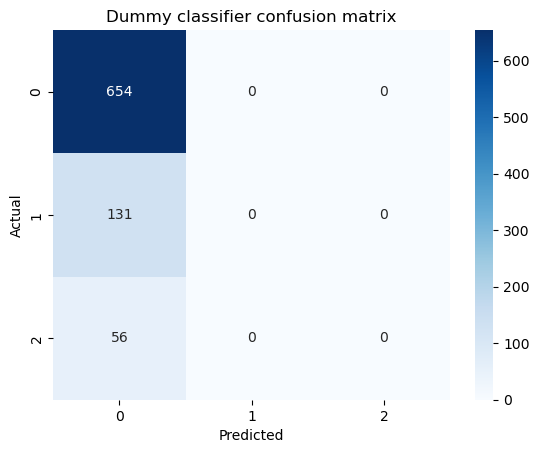

In [19]:
# make a dummy classifier for a baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(x_train, y_train)
y_dummy_pred = dummy.predict(x_test)
y_dummy_prob = dummy.predict_proba(x_test)

# Compute metrics
overall_accuracy = accuracy_score(y_test, y_dummy_pred)
macro_precision = precision_score(y_test, y_dummy_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_test, y_dummy_pred, average="macro")
overall_log_loss = log_loss(y_test, y_dummy_prob)
macro_f1 = f1_score(y_test, y_dummy_pred, average="macro")

# Output metrics
print("Dummy Accuracy:\t\t\t", overall_accuracy)
print("Dummy Precision:\t\t", macro_precision)
print("Dummy Recall:\t\t\t", macro_recall)
print("Dummy Log loss (cross-entropy):\t", overall_log_loss)
print("Dummy Macro f1:\t\t\t", macro_f1)

# Confusion matrix for dummy classifier
cm = confusion_matrix(y_test, y_dummy_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Dummy classifier confusion matrix")
plt.show()

In [20]:
# Random forest classifier model
rf = RandomForestClassifier(n_estimators = 500,
                            max_samples = 0.5, # for each tree, use half the rows to train that tree
                            max_features = 0.5, # for each tree, use half the columns to train that tree
                            max_depth = 10,
                            class_weight = 'balanced')
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [21]:
# analyze the random forest for feature importance
importance = pd.Series(rf.feature_importances_, index=feature_columns)
importance = importance.sort_values(ascending=False)
print(importance)

paint.quality         0.207309
gradient_energy       0.139687
vessel.id             0.112294
red_var               0.099477
laplacian_var         0.098772
entropy               0.094792
blue_var              0.089904
green_var             0.086424
niche.area.numeric    0.071341
dtype: float64


Accuracy:			 0.713436385255648
Precision:			 0.5012444575260417
Recall:				 0.5695098918714018
Log loss (cross-entropy):	 0.6428958391003184
Macro f1:			 0.5193499700198131


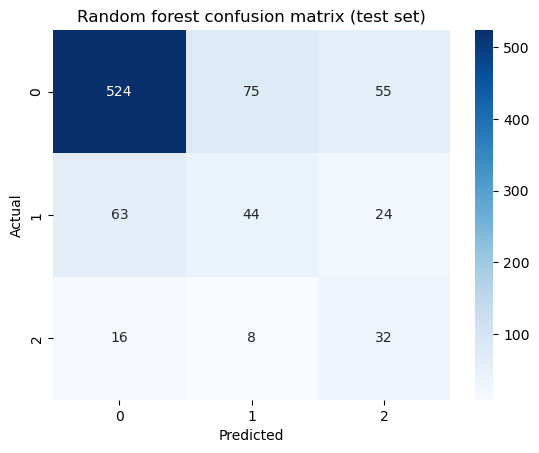

In [22]:
# Predictions (test set)
y_rf_pred = rf.predict(x_test)
y_rf_prob = rf.predict_proba(x_test)

# Overall metrics (test set)
overall_accuracy = accuracy_score(y_test, y_rf_pred)
macro_precision = precision_score(y_test, y_rf_pred, average="macro")
macro_recall = recall_score(y_test, y_rf_pred, average="macro")
overall_log_loss = log_loss(y_test, y_rf_prob)
macro_f1 = f1_score(y_test, y_rf_pred, average="macro")

print("Accuracy:\t\t\t", overall_accuracy)
print("Precision:\t\t\t", macro_precision)
print("Recall:\t\t\t\t", macro_recall)
print("Log loss (cross-entropy):\t", overall_log_loss)
print("Macro f1:\t\t\t", macro_f1)

# Confusion matrix (test set)
cm = confusion_matrix(y_test, y_rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random forest confusion matrix (test set)")
plt.show()

In [23]:
# ----------------------------
# Per-class metrics (test set)
# ----------------------------
classes = np.unique(y_test)

# Per-class accuracy: fraction correct within each true class
per_class_accuracy = {}
for c in classes:
    idx = y_test == c
    per_class_accuracy[c] = accuracy_score(y_test[idx], y_rf_pred[idx])
per_class_accuracy = pd.Series(per_class_accuracy)

# Per-class precision, recall, F1
per_class_precision = precision_score(y_test, y_rf_pred, labels=classes, average=None)
per_class_recall = recall_score(y_test, y_rf_pred, labels=classes, average=None)
per_class_f1 = f1_score(y_test, y_rf_pred, labels=classes, average=None)

# ----------------------------
# Combine into a single DataFrame
# ----------------------------
summary_df = pd.DataFrame({
    "accuracy": per_class_accuracy.values,
    "precision": per_class_precision,
    "recall": per_class_recall,
    "F1": per_class_f1
}, index=[f"Class {c}" for c in classes])

overall_row = pd.Series({
    "accuracy": overall_accuracy,
    "precision": macro_precision,
    "recall": macro_recall,
    "F1": macro_f1
}, name="Overall")

summary_df = pd.concat([summary_df, overall_row.to_frame().T])

# Add overall log loss separately
summary_df["log_loss"] = np.nan
summary_df.loc["Overall", "log_loss"] = overall_log_loss

print("Summary of random forest classifier model (test set)")
print(summary_df)

Summary of random forest classifier model (test set)
         accuracy  precision    recall        F1  log_loss
Class 0  0.801223   0.868988  0.801223  0.833731       NaN
Class 1  0.335878   0.346457  0.335878  0.341085       NaN
Class 2  0.571429   0.288288  0.571429  0.383234       NaN
Overall  0.713436   0.501244  0.569510  0.519350  0.642896


Accuracy:			 0.6171224732461356
Precision:			 0.5327619366835054
Recall:				 0.5213018959951057
Log loss (cross-entropy):	 0.8043525229486438
Macro f1:			 0.5184762046464174


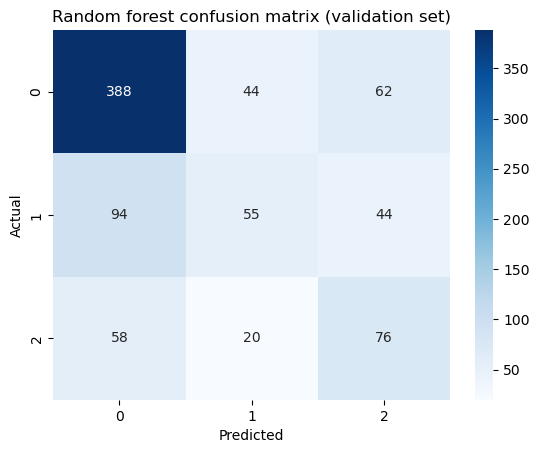

In [24]:
x_val = df_val[feature_columns]
y_val = df_val['SLoF']

# Predictions (validation set)
y_rf_pred = rf.predict(x_val)
y_rf_prob = rf.predict_proba(x_val)

# Overall metrics (validation set)
overall_accuracy = accuracy_score(y_val, y_rf_pred)
macro_precision = precision_score(y_val, y_rf_pred, average="macro")
macro_recall = recall_score(y_val, y_rf_pred, average="macro")
overall_log_loss = log_loss(y_val, y_rf_prob)
macro_f1 = f1_score(y_val, y_rf_pred, average="macro")

print("Accuracy:\t\t\t", overall_accuracy)
print("Precision:\t\t\t", macro_precision)
print("Recall:\t\t\t\t", macro_recall)
print("Log loss (cross-entropy):\t", overall_log_loss)
print("Macro f1:\t\t\t", macro_f1)

# Confusion matrix (validation set)
cm = confusion_matrix(y_val, y_rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random forest confusion matrix (validation set)")
plt.show()

In [25]:
# ----------------------------
# Per-class metrics (validation set)
# ----------------------------
classes = np.unique(y_val)

# Per-class accuracy: fraction correct within each true class
per_class_accuracy = {}
for c in classes:
    idx = y_val == c
    per_class_accuracy[c] = accuracy_score(y_val[idx], y_rf_pred[idx])
per_class_accuracy = pd.Series(per_class_accuracy)

# Per-class precision, recall, F1
per_class_precision = precision_score(y_val, y_rf_pred, labels=classes, average=None)
per_class_recall = recall_score(y_val, y_rf_pred, labels=classes, average=None)
per_class_f1 = f1_score(y_val, y_rf_pred, labels=classes, average=None)

# ----------------------------
# Combine into a single DataFrame
# ----------------------------
summary_df = pd.DataFrame({
    "accuracy": per_class_accuracy.values,
    "precision": per_class_precision,
    "recall": per_class_recall,
    "F1": per_class_f1
}, index=[f"Class {c}" for c in classes])

overall_row = pd.Series({
    "accuracy": overall_accuracy,
    "precision": macro_precision,
    "recall": macro_recall,
    "F1": macro_f1
}, name="Overall")

summary_df = pd.concat([summary_df, overall_row.to_frame().T])

# Add overall log loss separately
summary_df["log_loss"] = np.nan
summary_df.loc["Overall", "log_loss"] = overall_log_loss

print("Summary of random forest classifier model (validation set)")
print(summary_df)

Summary of random forest classifier model (validation set)
         accuracy  precision    recall        F1  log_loss
Class 0  0.785425   0.718519  0.785425  0.750484       NaN
Class 1  0.284974   0.462185  0.284974  0.352564       NaN
Class 2  0.493506   0.417582  0.493506  0.452381       NaN
Overall  0.617122   0.532762  0.521302  0.518476  0.804353
